In [ ]:
pip install yfinance fredapi

In [ ]:
pip install fredapi pandas_datareader

In [ ]:
# ==========================================
# ==========   IMPORTS & SETUP   ===========
# ==========================================
import yfinance as yf
import pandas_datareader.data as web  # <--- NECESARIO PARA FRED
import pandas as pd
import numpy as np
import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score

start_date = '2010-01-01'
end_date = datetime.date.today()

print("1. Descargando Datos de Mercado (S&P 500 y VIX)...")
market_tickers = ["^GSPC", "^VIX"]

market_data = yf.download(market_tickers, start=start_date, end=end_date, progress=False, auto_adjust=True)['Close']

market_data = market_data.rename(columns={"^GSPC": "SP500", "^VIX": "VIX"})

print("2. Descargando Indicadores Macro de FRED (Esto puede tardar)...")

print("2. Descargando Indicadores Macro de FRED (Esto puede tardar)...")
# Códigos de series en FRED:
# T10Y2Y: Curva de Tipos (10Y - 2Y) -> Predice recesiones
# DGS10: Tasa del Tesoro a 10 años -> Costo del dinero
# BAMLH0A0HYM2: High Yield Spread -> Riesgo de crédito corporativo
# T10YIE: Expectativa de Inflación a 10 años
# DEXUSEU: Tipo de cambio Dólar vs Euro
fred_series = ['T10Y2Y', 'DGS10', 'BAMLH0A0HYM2', 'T10YIE', 'DEXUSEU']

try:
    macro_data = web.DataReader(fred_series, 'fred', start_date, end_date)
except Exception as e:
    print(f"Error conectando con FRED: {e}")
    # Fallback: Si falla FRED, creamos un DF vacío para que no rompa, pero el script necesita internet.
    macro_data = pd.DataFrame()
df = market_data.join(macro_data).ffill().dropna()


# 1. Variables de Mercado
df["SP500_Ret"] = df["SP500"].pct_change()
df["VIX_Change"] = df["VIX"].diff() # El cambio en el miedo

# 2. Variables Macro (Diferencias diarias para estacionariedad)
df["Yield_Curve_Change"] = df["T10Y2Y"].diff()
df["Rate_10Y_Change"] = df["DGS10"].diff()
df["Credit_Spread_Change"] = df["BAMLH0A0HYM2"].diff()
df["Inflation_Exp_Change"] = df["T10YIE"].diff()
df["USD_EUR_Ret"] = df["DEXUSEU"].pct_change()

# 3. Target: ¿Subirá el S&P 500 MAÑANA?
# Shift(-1) porque usamos datos de HOY para predecir MAÑANA
df["Target"] = (df["SP500"].shift(-1) > df["SP500"]).astype(int)

df = df.dropna()

print(f"Total de días hábiles procesados: {len(df)}")

features = ["VIX", "VIX_Change",
            "Yield_Curve_Change", "Rate_10Y_Change",
            "Credit_Spread_Change", "Inflation_Exp_Change",
            "USD_EUR_Ret", "SP500_Ret"]

X = df[features]
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Features Originales: {X_train.shape[1]}")
print(f"Componentes PCA necesarios para 95% varianza: {pca.n_components_}")
print("Entrenando Modelos...")

# Modelo A: SVM con todas las variables Macro crudas
clf_no_pca = SVC(random_state=42)
clf_no_pca.fit(X_train_scaled, y_train)
pred_no_pca = clf_no_pca.predict(X_test_scaled)

# Modelo B: SVM con PCA (Factores Latentes)
clf_pca = SVC(random_state=42)
clf_pca.fit(X_train_pca, y_train)
pred_pca = clf_pca.predict(X_test_pca)

results = pd.DataFrame({
    "Modelo": ["SVM Macro (Sin PCA)", "SVM Macro (Con PCA)"],
    "Accuracy": [accuracy_score(y_test, pred_no_pca), accuracy_score(y_test, pred_pca)],
    "Precision": [precision_score(y_test, pred_no_pca), precision_score(y_test, pred_pca)]
})

print("\n===== RESULTADOS: S&P 500 vs MACROECONOMÍA =====")
print(results)

1. Descargando Datos de Mercado (S&P 500 y VIX)...
2. Descargando Indicadores Macro de FRED (Esto puede tardar)...
2. Descargando Indicadores Macro de FRED (Esto puede tardar)...
Total de días hábiles procesados: 4008
Features Originales: 8
Componentes PCA necesarios para 95% varianza: 7
Entrenando Modelos...

===== RESULTADOS: S&P 500 vs MACROECONOMÍA =====
                Modelo  Accuracy  Precision
0  SVM Macro (Sin PCA)  0.542394   0.554286
1  SVM Macro (Con PCA)  0.552369   0.559322


In [ ]:
# ==========================================
# ==========   IMPORTS & SETUP   ===========
# ==========================================
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score

# Función auxiliar para RSI (Relative Strength Index)
def calculate_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

# ==========================================
# ==========   1. MACRO DATA COMPLEX  ======
# ==========================================
print("1. Descargando Cluster Macroeconómico...")
# ^TNX: Bonos 10y, ^VIX: Miedo, CL=F: Petróleo, GC=F: Oro
macro_tickers = ["^TNX", "^VIX", "CL=F", "GC=F"]
macro = yf.download(macro_tickers, period="7y", interval="1d", progress=False)['Close']
macro = macro.ffill()

# Ingeniería de Features Macro
macro_feats = pd.DataFrame()
macro_feats["Rates_Chg"] = macro["^TNX"].diff()      # Cambio en tasas
macro_feats["VIX"]       = macro["^VIX"]             # Nivel de miedo
macro_feats["Oil_Ret"]   = macro["CL=F"].pct_change() # Retorno Petróleo
macro_feats["Gold_Ret"]  = macro["GC=F"].pct_change() # Retorno Oro

# Agregamos Lags Macro (¿Qué pasó con el petróleo ayer?)
for col in macro_feats.columns:
    macro_feats[f"{col}_lag1"] = macro_feats[col].shift(1)

# ==========================================
# ==========   2. DATA DE ACCIONES  ========
# ==========================================
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "AMD"]
all_data = []

print(f"2. Procesando Acciones con Memoria Temporal...")

for t in tickers:
    df = yf.download(t, period="7y", interval="1d", progress=False, auto_adjust=True)
    if isinstance(df.columns, pd.MultiIndex): df.columns = df.columns.get_level_values(0)

    # --- A. Variables Base ---
    df["Ret"] = df["Close"].pct_change()
    df["Vol_5"] = df["Ret"].rolling(5).std()
    df["RSI"] = calculate_rsi(df["Close"], window=14)

    # Distancia a Medias (Tendencia)
    df["Dist_MA20"] = (df["Close"] - df["Close"].rolling(20).mean()) / df["Close"]
    df["Dist_MA50"] = (df["Close"] - df["Close"].rolling(50).mean()) / df["Close"]

    # --- B. INYECCIÓN DE MEMORIA (LAGS) ---
    # El modelo verá lo que pasó hoy, ayer (t-1), anteayer (t-2) y hace 3 días (t-3)
    features_to_lag = ["Ret", "Vol_5", "RSI"]
    for f in features_to_lag:
        for lag in [1, 2, 3]:
            df[f"{f}_lag{lag}"] = df[f].shift(lag)

    # --- C. FUSIÓN MACRO ---
    df = df.merge(macro_feats, left_index=True, right_index=True, how="left")

    # Target
    df["Target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)

    df = df.dropna()
    all_data.append(df)

df_big = pd.concat(all_data)

# ==========================================
# ==========   3. DEFINICIÓN X e Y   =======
# ==========================================
# Excluimos columnas de precio absoluto o que no sean features
drop_cols = ["Open", "High", "Low", "Close", "Volume", "Target"]
# Seleccionamos dinámicamente todas las columnas numéricas que restan
X = df_big.drop(columns=[c for c in df_big.columns if c in drop_cols])
y = df_big["Target"]

print(f"--> Total de Features generados: {X.shape[1]}")

# ==========================================
# ==========   4. SPLIT & SCALING   ========
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# ==========   5. PCA (REDUCCIÓN)   ========
# ==========================================
# Aquí está la magia: Tenemos muchas columnas correlacionadas.
# PCA debe comprimirlas. Pedimos 95% de varianza.
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"--> Dimensiones reducidas por PCA: De {X_train.shape[1]} a {pca.n_components_}")

# ==========================================
# ==========   6. ENTRENAMIENTO DOBLE  =====
# ==========================================
print("Entrenando Modelos (esto puede tardar unos segundos)...")

# Modelo A: Full Dimension (Fuerza Bruta)
clf_full = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
clf_full.fit(X_train_scaled, y_train)
pred_full = clf_full.predict(X_test_scaled)

# Modelo B: PCA (Inteligente)
clf_pca = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
clf_pca.fit(X_train_pca, y_train)
pred_pca = clf_pca.predict(X_test_pca)

# ==========================================
# ==========   7. RESULTADOS   =============
# ==========================================
results = pd.DataFrame({
    "Modelo": ["SVM Full (Sin PCA)", "SVM Compacto (Con PCA)"],
    "Features": [X_train.shape[1], pca.n_components_],
    "Accuracy": [accuracy_score(y_test, pred_full), accuracy_score(y_test, pred_pca)],
    "Precision": [precision_score(y_test, pred_full), precision_score(y_test, pred_pca)]
})

print("\n===== RESULTADOS EXPERIMENTO COMPLEJO =====")
print(results)

1. Descargando Cluster Macroeconómico...


/tmp/ipython-input-3039735889.py:27: FutureWarning: YF.download() has changed argument auto_adjust default to True
  macro = yf.download(macro_tickers, period="7y", interval="1d", progress=False)['Close']


2. Procesando Acciones con Memoria Temporal...
--> Total de Features generados: 22
--> Dimensiones reducidas por PCA: De 22 a 14
Entrenando Modelos (esto puede tardar unos segundos)...

===== RESULTADOS EXPERIMENTO COMPLEJO =====
                   Modelo  Features  Accuracy  Precision
0      SVM Full (Sin PCA)        22  0.558062   0.550690
1  SVM Compacto (Con PCA)        14  0.550961   0.544186


In [ ]:

import yfinance as yf
import pandas_datareader.data as web
import pandas as pd
import numpy as np
import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score

# Función RSI (Indicador Técnico de Momento)
def calculate_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

print("1. Descargando Datos de Mercado (Precios, VIX, Commodities)...")
start_date = '2015-01-01'
end_date = datetime.date.today()

# ^GSPC: S&P500, ^VIX: Miedo, CL=F: Petróleo, GC=F: Oro
tickers = ["^GSPC", "^VIX", "CL=F", "GC=F"]

market_data = yf.download(tickers, start=start_date, end=end_date, progress=False, auto_adjust=True)['Close']
market_data.columns = ["SP500", "Oil", "Gold", "VIX"] # Renombrar para facilitar

print("2. Descargando Datos Económicos Profundos (FRED)...")
# T10Y2Y: Curva de Tipos (Predice recesiones)
# BAMLH0A0HYM2: High Yield Spread (Riesgo de crédito)
# T10YIE: Expectativas de Inflación a 10 años
fred_series = ['T10Y2Y', 'BAMLH0A0HYM2', 'T10YIE']

try:
    macro_data = web.DataReader(fred_series, 'fred', start_date, end_date)
    macro_data.columns = ["Yield_Curve", "Credit_Spread", "Inflation_Exp"]
except Exception as e:
    print(f"Error con FRED: {e}. Usando datos vacíos.")
    macro_data = pd.DataFrame()

df = market_data.join(macro_data).ffill().dropna()

print("3. Generando Alta Dimensionalidad (Indicadores + Lags)...")

# --- A. Variables Objetivo y Técnicas ---
df["Ret_SP500"] = df["SP500"].pct_change()
df["RSI"]       = calculate_rsi(df["SP500"])
df["Vol_20"]    = df["Ret_SP500"].rolling(20).std()

df["VIX_Chg"]      = df["VIX"].diff()
df["Oil_Ret"]      = df["Oil"].pct_change()
df["Gold_Ret"]     = df["Gold"].pct_change()
df["Curve_Chg"]    = df["Yield_Curve"].diff()
df["Spread_Chg"]   = df["Credit_Spread"].diff()
df["Inflation_Chg"]= df["Inflation_Exp"].diff()

base_features = ["Ret_SP500", "RSI", "Vol_20", "VIX_Chg", "Oil_Ret",
                 "Gold_Ret", "Curve_Chg", "Spread_Chg", "Inflation_Chg"]

for feat in base_features:
    for lag in [1, 2, 3, 4, 5]: # 5 días de historia para cada variable
        df[f"{feat}_L{lag}"] = df[feat].shift(lag)

# Target: ¿Sube el S&P 500 mañana?
df["Target"] = (df["SP500"].shift(-1) > df["SP500"]).astype(int)
df = df.dropna()

# Quitamos las columnas de precio absoluto que no sirven para predecir (solo usamos cambios)
cols_to_drop = ["SP500", "Oil", "Gold", "VIX", "Yield_Curve", "Credit_Spread", "Inflation_Exp", "Target"]
# Asegurarnos de borrar solo las que existen
cols_to_drop = [c for c in cols_to_drop if c in df.columns]

X = df.drop(columns=cols_to_drop)
y = df["Target"]

print(f"--> Total Features (Input): {X.shape[1]}") # Deberían ser muchas (ej. 50+)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Pedimos que capture el 95% de la varianza económica
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"--> Dimensiones PCA (Output): {pca.n_components_}")

print("Entrenando Modelos...")

# Modelo Full (Ruido + Señal)
clf_full = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
clf_full.fit(X_train_scaled, y_train)
pred_full = clf_full.predict(X_test_scaled)

# Modelo PCA (Solo Señal Latente)
clf_pca = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
clf_pca.fit(X_train_pca, y_train)
pred_pca = clf_pca.predict(X_test_pca)

results = pd.DataFrame({
    "Modelo": ["SVM Macro Full", "SVM Macro PCA"],
    "Features": [X_train.shape[1], pca.n_components_],
    "Accuracy": [accuracy_score(y_test, pred_full), accuracy_score(y_test, pred_pca)],
    "Precision": [precision_score(y_test, pred_full), precision_score(y_test, pred_pca)]
})

print("\n===== S&P 500: EXPERIMENTO MACRO COMPLEJO =====")
print(results)

1. Descargando Datos de Mercado (Precios, VIX, Commodities)...
2. Descargando Datos Económicos Profundos (FRED)...
3. Generando Alta Dimensionalidad (Indicadores + Lags)...
--> Total Features (Input): 54
--> Dimensiones PCA (Output): 36
Entrenando Modelos...

===== S&P 500: MACRO COMPLEX EXPERIMENT =====
           Modelo  Features  Accuracy  Precision
0  SVM Macro Full        54  0.494505   0.488739
1   SVM Macro PCA        36  0.505495   0.495536


1. Conectando con FRED usando tu API Key...
--> Features Totales: 34


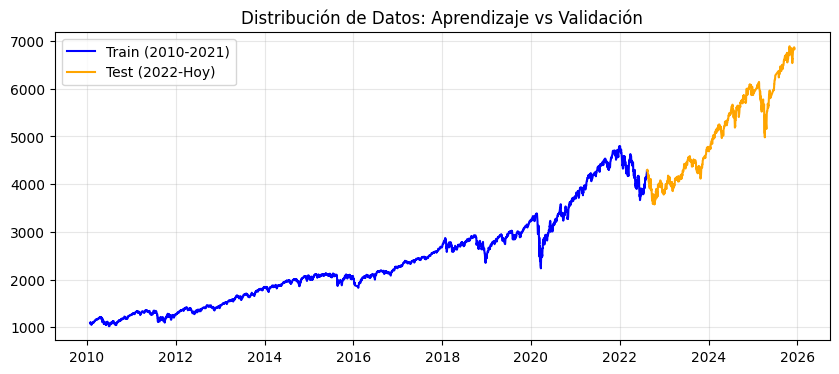

Entrenando Modelos LDA...
Evaluando con umbral de: 0.55

==================== LDA con PCA (Varianza) ====================
              precision    recall  f1-score   support

           0       0.45      0.65      0.53       362
           1       0.52      0.32      0.39       424

    accuracy                           0.47       786
   macro avg       0.48      0.48      0.46       786
weighted avg       0.48      0.47      0.46       786



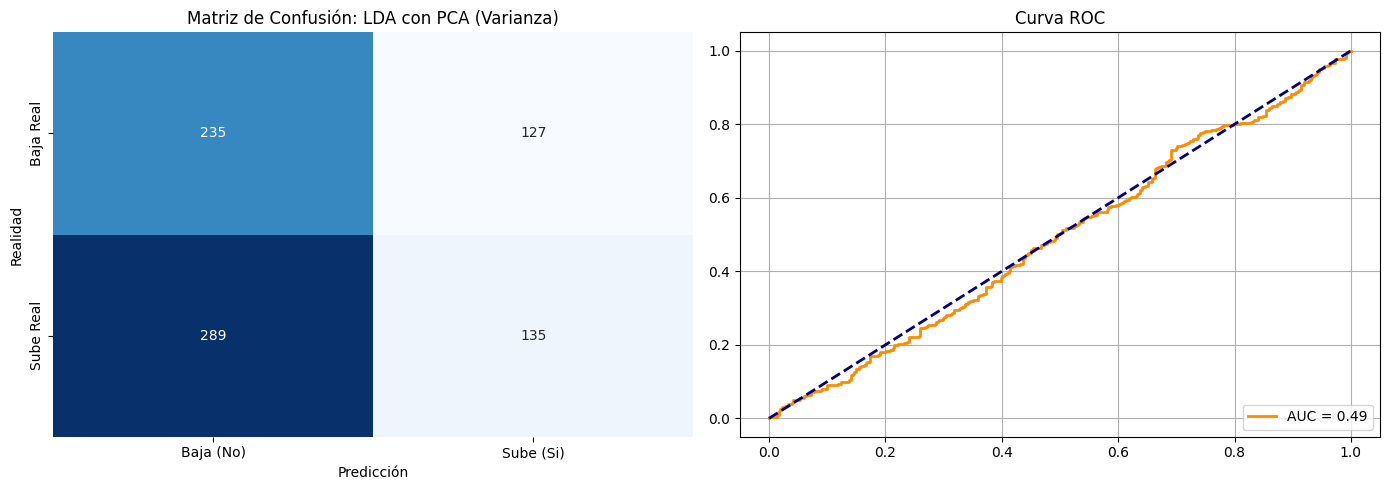


==================== LDA con Factor Analysis (Latente) ====================
              precision    recall  f1-score   support

           0       0.46      0.69      0.55       362
           1       0.54      0.31      0.39       424

    accuracy                           0.48       786
   macro avg       0.50      0.50      0.47       786
weighted avg       0.50      0.48      0.47       786



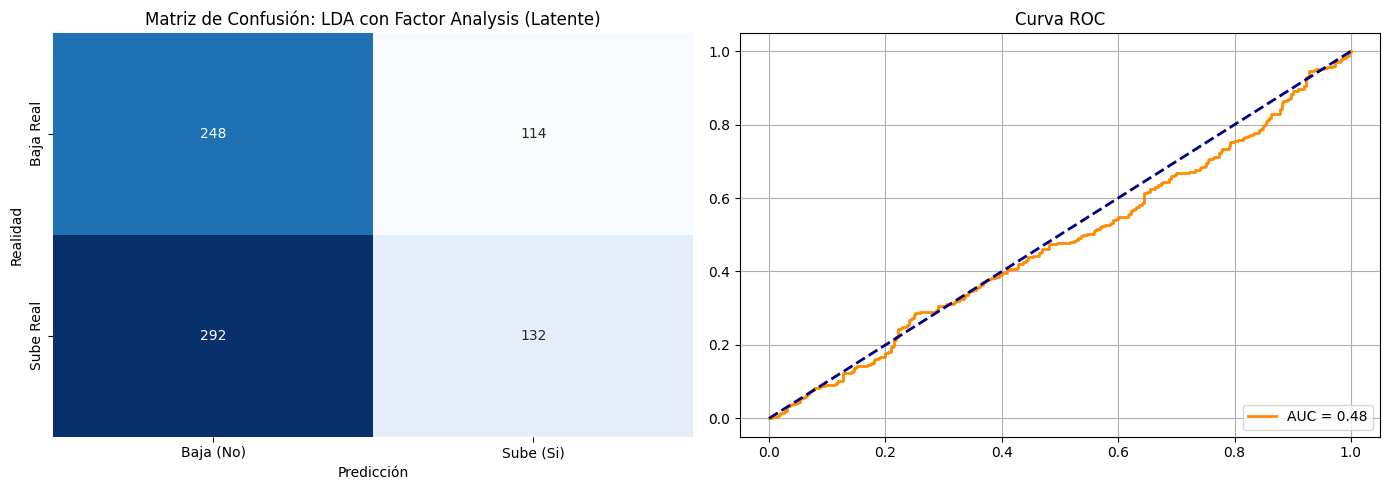

In [ ]:
import yfinance as yf
from fredapi import Fred  # <--- USAMOS TU LIBRERÍA CON KEY
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# --- INDICADORES TÉCNICOS EXTRA ---
def calculate_macd(series, fast=12, slow=26, signal=9):
    exp1 = series.ewm(span=fast, adjust=False).mean()
    exp2 = series.ewm(span=slow, adjust=False).mean()
    macd = exp1 - exp2
    return macd

def calculate_atr(high, low, close, window=14):
    high_low = high - low
    high_close = np.abs(high - close.shift())
    low_close = np.abs(low - close.shift())
    ranges = pd.concat([high_low, high_close, low_close], axis=1)
    true_range = np.max(ranges, axis=1)
    return true_range.rolling(window=window).mean()

print("1. Conectando con FRED usando tu API Key...")

fred = Fred(api_key="758fd07218bd0888111a0f6c24a9dec1")

start_date = '2010-01-01'
end_date = datetime.date.today()

fred_tickers = {
    'Curve': 'T10Y2Y',
    'Credit_Spread': 'BAMLH0A0HYM2',
    'Rates_10Y': 'DGS10',
    'Inflation_Exp': 'T10YIE'
}

macro_data = {}
for name, code in fred_tickers.items():
    try:
        # Descargamos usando tu cliente autenticado
        series = fred.get_series(code, observation_start=start_date)
        macro_data[name] = series
    except Exception as e:
        print(f"Error descargando {name}: {e}")

macro = pd.DataFrame(macro_data)

# B. Mercado (Yahoo)
tickers = ["^GSPC", "^VIX", "CL=F", "^RUT", "DX-Y.NYB"]
try:
    raw_market = yf.download(tickers, start=start_date, end=end_date, progress=False, auto_adjust=True)
    market = raw_market['Close'].copy()
    market.columns = ["Oil", "DXY", "SP500", "Russell2000", "VIX"]

    # Datos para ATR
    sp500_high = raw_market['High']['^GSPC']
    sp500_low = raw_market['Low']['^GSPC']
except:
    print("Error Yahoo.")
    market = pd.DataFrame()

# Unir todo
df = market.join(macro).ffill().dropna()

df["Ret_SP500"] = df["SP500"].pct_change()
df["Ret_Russell"] = df["Russell2000"].pct_change()
df["Ret_Oil"]   = df["Oil"].pct_change()
df["Ret_DXY"]   = df["DXY"].pct_change()
df["Chg_VIX"]   = df["VIX"].diff()
df["Chg_Curve"] = df["Curve"].diff()
df["Chg_Spread"]= df["Credit_Spread"].diff()
df["Chg_Rates"] = df["Rates_10Y"].diff()

# Técnicos
df["MACD"] = calculate_macd(df["SP500"])
df["ATR"]  = calculate_atr(sp500_high, sp500_low, df["SP500"])

# Memory Injection (Lags)
features_base = ["Ret_SP500", "Ret_Russell", "Ret_DXY", "Chg_VIX",
                 "Chg_Spread", "Chg_Rates", "MACD", "ATR"]

for f in features_base:
    for lag in [1, 2, 3]:
        df[f"{f}_L{lag}"] = df[f].shift(lag)

# Target
df["Target"] = (df["SP500"].shift(-1) > df["SP500"]).astype(int)
df = df.dropna()

drop_cols = ["SP500", "Oil", "VIX", "Russell2000", "DXY",
             "Curve", "Credit_Spread", "Rates_10Y", "Inflation_Exp", "Target"]
X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y = df["Target"]

print(f"--> Features Totales: {X.shape[1]}")

split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# GRÁFICA 1: Distribución Temporal
plt.figure(figsize=(10, 4))
plt.plot(df.index[:split_idx], df['SP500'][:split_idx], label='Train (2010-2021)', color='blue')
plt.plot(df.index[split_idx:], df['SP500'][split_idx:], label='Test (2022-Hoy)', color='orange')
plt.title(f"Distribución de Datos: Aprendizaje vs Validación")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

N_COMPS = 10

# PCA
pca = PCA(n_components=N_COMPS, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# FA
fa = FactorAnalysis(n_components=N_COMPS, random_state=42)
X_train_fa = fa.fit_transform(X_train_scaled)
X_test_fa = fa.transform(X_test_scaled)

print("Entrenando Modelos LDA...")
lda_pca = LinearDiscriminantAnalysis()
lda_pca.fit(X_train_pca, y_train)
probs_pca = lda_pca.predict_proba(X_test_pca)[:, 1]

lda_fa = LinearDiscriminantAnalysis()
lda_fa.fit(X_train_fa, y_train)
probs_fa = lda_fa.predict_proba(X_test_fa)[:, 1]

def evaluar_modelo_grafico(y_true, probs, threshold, titulo):
    preds = (probs > threshold).astype(int)

    print(f"\n{'='*20} {titulo} {'='*20}")
    print(classification_report(y_true, preds))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # GRÁFICA 2: Matriz de Confusión
    cm = confusion_matrix(y_true, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
                xticklabels=['Baja (No)', 'Sube (Si)'],
                yticklabels=['Baja Real', 'Sube Real'])
    axes[0].set_title(f"Matriz de Confusión: {titulo}")
    axes[0].set_ylabel('Realidad')
    axes[0].set_xlabel('Predicción')

    # GRÁFICA 3: Curva ROC
    fpr, tpr, _ = roc_curve(y_true, probs)
    roc_auc = auc(fpr, tpr)

    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_title(f"Curva ROC")
    axes[1].legend(loc="lower right")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

# Configuración de Riesgo (Moderada para ver trades)
COST_FP = 1.2
threshold = COST_FP / (COST_FP + 1.0) # ~0.54

print(f"Evaluando con umbral de: {threshold:.2f}")

# --- EVALUACIÓN PCA ---
evaluar_modelo_grafico(y_test, probs_pca, threshold, "LDA con PCA (Varianza)")

# --- EVALUACIÓN FA ---
evaluar_modelo_grafico(y_test, probs_fa, threshold, "LDA con Factor Analysis (Latente)")